# Three ways to compute the external Q

A mode whose frequency lies above the beam-pipe cutoff does not stay in the cavity. It
propagates out along the pipe, and the rate at which it does is the external quality
factor $Q_{\rm ext}$. An eigenmode solve with closed pipe ends cannot see this: the end
wall reflects the wave straight back. To get $Q_{\rm ext}$ the pipe has to end in
something that lets the energy leave, and cavsim2d can do that three ways. Two of them
are boundary conditions, set like any other in `eigenmode_config['boundary_conditions']`.

| method | how the energy leaves | how to run it | $Q_{\rm ext}$ column |
|---|---|---|---|
| PML | a complex-stretched absorbing layer on each pipe end | `boundary_conditions='oo'` | `Q_eig []` |
| waveguide ports | the exact modal impedance of the pipe, a transparent boundary | `boundary_conditions='port'` | `Q_ext []` |
| lossy absorber | a physical absorbing cone in the pipe, ends closed | `cav.add_dielectric(..., tan_delta=...)` | `Q_diel []` |

The PML is the default open boundary, and the one that works for every polarisation; the
ports are for the monopole. The three share nothing but the cavity, so where they agree
the answer is not an artefact of any one of them.

This example solves the same TESLA 3-cell cavity all three ways and compares
$Q_{\rm ext}$, first for the modes trapped below the cutoff and then for the modes that
radiate above it.

In [1]:
import os
import tempfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cavsim2d import EllipticalCavity
from cavsim2d.utils.style import apply_style, WARM

apply_style()             # the house publication style
WORK = tempfile.mkdtemp() # docs runs leave nothing behind
C0 = 299_792_458.0

#                A      B      a     b    Ri       L       Req    [mm]
MIDCELL   = [42.00, 42.00, 12.0, 19.0, 35.0, 57.6520, 103.3536]
ENDCELL_L = [40.34, 40.34, 10.0, 13.5, 39.0, 55.7251, 103.3536]
ENDCELL_R = [42.00, 42.00,  9.0, 12.8, 39.0, 56.8407, 103.3536]

R_PIPE = ENDCELL_L[4]                                        # beam pipe radius [mm]
F_CUT = 2.405 * C0 / (2 * np.pi * R_PIPE * 1e-3) * 1e-6      # TM01 cutoff [MHz]
PIPE = 0.20                                                  # beam pipe length [m]
MESH = {'h': 12, 'p': 3}
N_MODES = 30


def tesla(name):
    cav = EllipticalCavity(3, MIDCELL, ENDCELL_L, ENDCELL_R, beampipe='both', name=name)
    cav.set_workspace(os.path.join(WORK, name))
    return cav


print(f'beam pipe radius {R_PIPE:.0f} mm, TM01 cutoff {F_CUT:.0f} MHz')

beam pipe radius 39 mm, TM01 cutoff 2942 MHz


## 1. PML: an absorbing layer on each pipe end

`boundary_conditions='oo'` attaches a perfectly matched layer to both pipe ends. The
eigenvalue becomes complex, and its imaginary part is the rate at which the mode loses
energy through the pipes:

$$Q_{\rm ext} = \frac{{\rm Re}\,\omega}{2\,|{\rm Im}\,\omega|}.$$

That is the `Q_eig []` column. `Q []` next to it is the total, with the wall loss added.

Above the cutoff an open solve returns two kinds of mode: resonances of the cavity, and
standing waves of the pipe and the layer that happen to leak. They look alike in the
table. The way to tell them apart is to solve again with a longer pipe. A cavity mode does
not care how long the pipe is, so its frequency stays put; a pipe mode moves.
`stable_modes` keeps the modes the second solve also found.

The test is on frequency alone (`rtol_q=np.inf`). The $Q$ of a mode close to the cutoff
converges slowly with pipe length, because the layer still reaches its evanescent tail,
and a combined test would throw such a mode away although it is a genuine cavity mode.

In [2]:
def solve_pml(name, pipe_length):
    cav = tesla(name)
    cav.eigenmode.run({'boundary_conditions': 'oo', 'n_modes': N_MODES,
                       'beampipe_length': pipe_length, 'mesh_config': MESH})
    return cav


cav_pml = solve_pml('pml', PIPE)
cav_pml_long = solve_pml('pml_long', 1.5 * PIPE)

pml = cav_pml.eigenmode.qois_df.sort_values('freq [MHz]')
pml_long = cav_pml_long.eigenmode.qois_df.sort_values('freq [MHz]')

# Judge only where both solves have modes: each returns its lowest N_MODES, and a mode
# above the other run's highest has nothing to be matched against.
f_top = min(pml['freq [MHz]'].max(), pml_long['freq [MHz]'].max())
pml = pml[pml['freq [MHz]'] <= f_top].copy()
stable = cav_pml.eigenmode.stable_modes(cav_pml_long.eigenmode, rtol_f=3e-4, rtol_q=np.inf)
pml['cavity mode'] = pml.index.isin(stable.index)

above = pml['freq [MHz]'] > F_CUT
print(f'{len(pml)} modes up to {f_top:.0f} MHz; above the cutoff '
      f'{int((above & pml["cavity mode"]).sum())} stay put and '
      f'{int((above & ~pml["cavity mode"]).sum())} move with the pipe')

27 modes up to 3702 MHz; above the cutoff 3 stay put and 12 move with the pipe


## 2. Waveguide ports: the exact boundary

`boundary_conditions='port'` terminates each pipe in its own modal impedance. For a
monopole mode the pipe modes are TM$_{0n}$ and known analytically; `n_port_modes`
(default 3) sets how many are kept per end. Below its cutoff a pipe mode does not
propagate, and the port adds only a reactance: the mode is pulled in frequency but not
damped, which is the correct physics for a trapped mode.

The port impedance depends on the frequency being solved for. The solver evaluates it at
each mode's closed-cavity frequency and solves once. That is accurate while a mode stays
close to where it started, which covers trapped and mildly damped modes, and it drifts
for strongly damped ones.

In [3]:
cav_ports = tesla('ports')
cav_ports.eigenmode.run({'boundary_conditions': 'port', 'n_modes': N_MODES,
                         'beampipe_length': PIPE, 'mesh_config': MESH})
ports = cav_ports.eigenmode.qois_df.sort_values('freq [MHz]').reset_index(drop=True)
print(f'{len(ports)} modes up to {ports["freq [MHz]"].max():.0f} MHz')

30 modes up to 3852 MHz


## 3. A lossy absorber in the pipe

The third way needs no special boundary at all: put a real absorber in the pipe and close
the ends. Here it is a solid cone of lossy ceramic at each end, full-bore at the end wall
and tapering to a point on the axis, so that a wave cannot slip past it. The damping is
then ordinary dielectric loss, solved by the complex eigensolver.

The absorber brings resonances of its own. They are easy to separate, because for a
small loss $Q_{\rm diel} \approx 1/(\eta \tan\delta)$, with $\eta$ the fraction of the
mode's electric energy inside the absorber:

$$\eta = \frac{1}{Q_{\rm diel}\tan\delta}.$$

A cavity mode has $\eta \approx 0$; a resonance of the absorber has $\eta$ of order one.

C:\Users\Soske\Documents\git_projects\cavsim2d\cavsim2d\solvers\NGSolve\eigen_ngsolve.py:1783: UserWarning: lossy eigensolve: 26 distinct mode(s) for 33 requested — the pooled Arnoldi pairs did not contain enough distinct eigenvalues. The modes are renumbered, so check 'mode_of_interest' against the reported frequencies; raising eigenmode_config['arnoldi_vectors'] (currently 6) may separate them.
  return self._solve_lossy_system(mesh, mesh_p, m_pol, materials, lam_shifts,


26 modes up to 3738 MHz, 5 of them resonances of the absorber


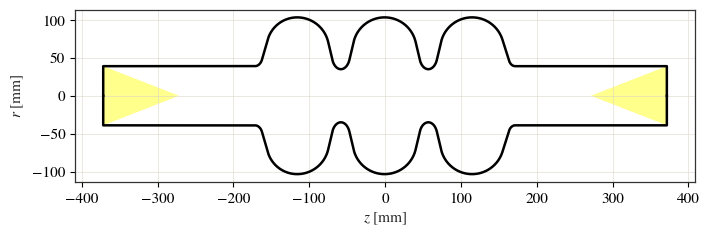

In [4]:
CONE = {'length': 100.0, 'eps_r': 10.0, 'tan_delta': 0.3, 'maxh': 4.0}   # mm

cav_cone = tesla('cone')
pipe_end = max(z for z, _ in cav_cone.profile(beampipe_length=PIPE).points) * 1e3   # mm
for side in (+1, -1):
    base = side * pipe_end
    cav_cone.add_dielectric(f'absorber_{"right" if side > 0 else "left"}',
                            CONE['eps_r'], tan_delta=CONE['tan_delta'], maxh=CONE['maxh'],
                            points=[(base - side * CONE['length'], 0.0),
                                    (base, R_PIPE), (base, 0.0)])

cav_cone.eigenmode.run({'boundary_conditions': 'mm', 'n_modes': 45,
                        'beampipe_length': PIPE, 'mesh_config': MESH})
cone = cav_cone.eigenmode.qois_df.sort_values('freq [MHz]').reset_index(drop=True)
cone['eta'] = 1.0 / (cone['Q_diel []'] * CONE['tan_delta'])
cone['cavity mode'] = cone['eta'] < 0.2
print(f'{len(cone)} modes up to {cone["freq [MHz]"].max():.0f} MHz, '
      f'{int((~cone["cavity mode"]).sum())} of them resonances of the absorber')
cav_cone.plot('geometry', mirror=True)
plt.show()

## 4. Below the cutoff: trapped modes

A mode below the cutoff cannot propagate in the pipe, so it does not radiate at all: its
true $Q_{\rm ext}$ is infinite, and its only loss is the wall. Each method is matched to
the PML modes by frequency.

In [5]:
def nearest(df, f, col):
    """The mode of *df* nearest to *f*: its frequency and its *col*."""
    j = int(np.argmin(np.abs(df['freq [MHz]'].to_numpy() - f)))
    return df['freq [MHz]'].iloc[j], df[col].iloc[j]


pml_long_q = dict(zip(pml_long['freq [MHz]'], pml_long['Q_eig []']))
rows = []
for _, m in pml[pml['freq [MHz]'] < F_CUT].iterrows():
    f = m['freq [MHz]']
    rows.append({'f [MHz]': f, 'R/Q [Ohm]': m['R/Q [Ohm]'],
                 f'PML, {PIPE * 1e3:.0f} mm pipe': m['Q_eig []'],
                 f'PML, {PIPE * 1.5e3:.0f} mm pipe': nearest(pml_long, f, 'Q_eig []')[1],
                 'ports': nearest(ports, f, 'Q_ext []')[1],
                 'absorber': nearest(cone, f, 'Q_diel []')[1],
                 'Q0, copper walls': m['Q []']})
trapped = pd.DataFrame(rows)
trapped.style.format({c: '{:.3g}' for c in trapped.columns if c != 'f [MHz]'}
                     | {'f [MHz]': '{:.2f}'})

,f [MHz],R/Q [Ohm],"PML, 200 mm pipe","PML, 300 mm pipe",ports,absorber,"Q0, copper walls"
0,1281.68,0.0274,9.8e+17,7.38e+19,4.05e+26,2.13e+08,2.93e+04
1,1293.83,0.00423,3.09e+17,2.78e+19,1.07e+26,6.45e+07,2.94e+04
2,1300.01,332,4.1e+17,2.73e+19,7.27e+25,9.18e+07,2.93e+04
3,2391.16,1.26,7.56e+11,9.95e+14,1.32e+23,4.11e+05,3.17e+04
4,2420.56,15.3,2.15e+11,2.38e+14,1.21e+23,1.88e+05,3.17e+04
5,2450.88,84,1.34e+11,1.23e+14,1.37e+22,1.83e+05,3.11e+04
6,2488.07,1.21e-26,2.68e+20,1.45e+20,5.29e+27,2.39e+12,5.43e+04
7,2500.61,1.46e-24,2.43e+20,7.45e+20,2.15e+26,3.27e+13,5.36e+04
8,2506.66,1.4e-25,1.93e+20,3.03e+19,5.38e+25,2.37e+12,5.39e+04
9,2680.44,0.0967,1.98e+09,3.2e+11,9.44e+20,2.51e+04,4.45e+04


All three agree that nothing radiates below the cutoff. They disagree about how
completely.

- The ports return $Q_{\rm ext}$ of $10^{20}$ and more, which is numerically infinite.
  Below its cutoff a pipe mode only adds a reactance, so nothing damps the cavity mode,
  and that is exact.
- The PML returns $10^{8}$ to $10^{20}$, and the value grows with the pipe length. The
  layer reaches the mode's evanescent tail and absorbs a sliver of it; move the layer
  further away and it absorbs less. In practice it never matters: every value is orders
  of magnitude above the wall $Q_0$ of a few $10^4$, so the total $Q$ is the wall's.
- The absorber returns $10^{7}$ to $10^{8}$ for the fundamental passband and between
  about $10^{4}$ and $4\times10^{5}$ for the higher modes just below the cutoff, the same
  order as the copper wall. That is not a numerical error. The evanescent tail of those
  modes reaches the cone and the cone damps it, so this is the $Q$ of the cavity with
  that absorber 200 mm away. It is the right answer to a different question: it is not
  the external $Q$ of an open pipe, and it changes with where the absorber is put.

## 5. Above the cutoff: radiating modes

Above the cutoff $Q_{\rm ext}$ is finite, and the comparison is between the cavity
modes that survived the pipe-length test in section 1. Two numbers per method: how far
its nearest mode sits from the PML one, in units of the PML linewidth $f/Q$, and its
$Q_{\rm ext}$. An offset well below one linewidth is the same resonance; an offset of
order one is not.

In [6]:
rows = []
for _, m in pml[(pml['freq [MHz]'] > F_CUT) & pml['cavity mode']].iterrows():
    f, q = m['freq [MHz]'], m['Q_eig []']
    width = f / q
    fp, qp = nearest(ports, f, 'Q_ext []')
    fc, qc = nearest(cone[cone['cavity mode']], f, 'Q_diel []')
    rows.append({'f [MHz]': f, 'R/Q [Ohm]': m['R/Q [Ohm]'],
                 'Q_ext, PML': q,
                 f'Q_ext, PML {PIPE * 1.5e3:.0f} mm': nearest(pml_long, f, 'Q_eig []')[1],
                 'ports: offset [f/Q]': abs(fp - f) / width, 'Q_ext, ports': qp,
                 'absorber: offset [f/Q]': abs(fc - f) / width, 'Q_ext, absorber': qc})
radiating = pd.DataFrame(rows)
radiating.style.format({c: '{:.3g}' for c in radiating.columns if c != 'f [MHz]'}
                       | {'f [MHz]': '{:.2f}'})

,f [MHz],R/Q [Ohm],"Q_ext, PML","Q_ext, PML 300 mm",ports: offset [f/Q],"Q_ext, ports",absorber: offset [f/Q],"Q_ext, absorber"
0,3431.87,2.24,57.2,57.1,0.0281,52.8,0.243,36.6
1,3506.24,19.3,16.9,17,0.209,20.6,0.0634,34.3
2,3595.54,34.5,15.4,15.4,0.197,20.6,0.326,34.3


Three modes above the cutoff stay put when the pipe is lengthened, and so does their
PML $Q_{\rm ext}$, to better than half a percent: about 57, 17 and 15. Those are
cavity resonances with a well-defined external $Q$. The twelve modes that moved belong
to the pipe.

- The ports find the first of the three, the narrowest, at the same frequency (0.03
  linewidths away) with a $Q_{\rm ext}$ 8% lower. For the two broader ones the nearest
  port mode is a single resonance at 3550 MHz, a fifth of a linewidth from each. The
  port impedance is evaluated at the closed-cavity frequency and the mode is solved
  once, and that cannot follow a mode which moves this far when the pipe opens.
- The absorber puts a mode within a third of a linewidth of each of the three, with the
  two broader PML modes sharing one absorber mode, but its $Q$ is between 0.6 and 2.2
  times the PML value. The cone reflects part of the outgoing wave back into the cavity,
  which an open pipe does not do, so its $Q$ again describes that absorber rather than
  the open pipe.

Everything on one plot: $Q_{\rm ext}$ against frequency for the three methods. Filled
markers are cavity modes, open markers the modes each method flags as its own artefacts:
PML modes that moved with the pipe, and resonances of the absorber.

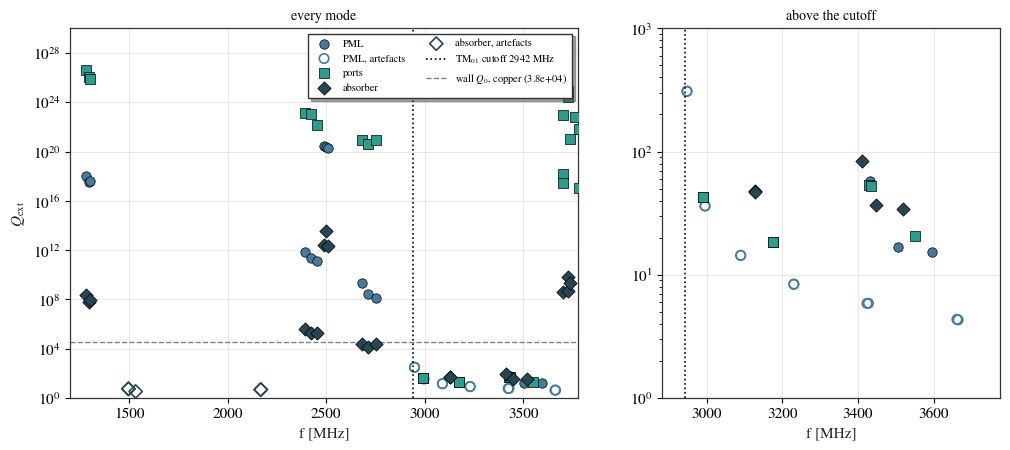

In [7]:
fig, (ax, zoom) = plt.subplots(1, 2, figsize=(12, 4.8),
                               gridspec_kw={'width_ratios': [3, 2]})
styles = [('PML', pml, 'Q_eig []', 'o', WARM[0]),
          ('ports', ports.assign(**{'cavity mode': True}), 'Q_ext []', 's', WARM[2]),
          ('absorber', cone, 'Q_diel []', 'D', WARM[4])]
q_wall = trapped['Q0, copper walls'].median()
for a in (ax, zoom):
    for name, df, col, marker, colour in styles:
        real = df['cavity mode'].to_numpy(bool)
        a.scatter(df['freq [MHz]'][real], df[col][real], marker=marker, s=46,
                  color=colour, edgecolor='k', linewidth=0.5, zorder=3, label=name)
        if (~real).any():
            a.scatter(df['freq [MHz]'][~real], df[col][~real], marker=marker, s=46,
                      facecolor='none', edgecolor=colour, linewidth=1.2, zorder=2,
                      label=f'{name}, artefacts')
    a.axvline(F_CUT, ls=':', color='k', lw=1.2,
              label=f'TM$_{{01}}$ cutoff {F_CUT:.0f} MHz')
    a.axhline(q_wall, ls='--', color='0.5', lw=1.0,
              label=f'wall $Q_0$, copper ({q_wall:.1e})')
    a.set_yscale('log')
    a.set_xlabel('f [MHz]')

ax.set_ylim(1, 1e30)
ax.set_xlim(1200, f_top * 1.02)
ax.set_ylabel(r'$Q_{\rm ext}$')
ax.set_title('every mode', fontsize=10)
zoom.set_xlim(F_CUT - 60, f_top * 1.02)
zoom.set_ylim(1, 1e3)
zoom.set_title('above the cutoff', fontsize=10)
ax.legend(fontsize=7.5, ncol=2, loc='upper right')
plt.show()

## What to take away

- Use the PML, the default. For a radiating mode it gives the external $Q$ of an open
  pipe; for a trapped mode it gives a value so large that the wall loss decides the
  total $Q$.
- Solve twice with different pipe lengths and keep the modes that stay put. Above the
  cutoff most of what an open solve returns belongs to the pipe, twelve of fifteen modes
  here. This is also the test that filters modes before an impedance is reconstructed
  from them (see the open-boundary impedance example in the wakefield section). It is
  the best discriminant available, and it is not perfect: a genuine mode can be dropped
  and a pipe mode can survive.
- The ports are the independent check. They are exact below the cutoff, and above it
  they agree with the PML on the narrowest radiating mode here. On broad modes the
  single-pass port solve drifts, so a disagreement there says more about the ports than
  about the PML.
- The absorber answers a different question: how strongly a real absorber at a given
  position damps each mode, trapped modes included. Use it to design an absorber, not
  to measure $Q_{\rm ext}$.